# **Projeto de Machine Learning**

## **APS2: Classificação**

### **Alunos:**

* Antonio Iranilson Honorato dos Santos Junior 
* Esthefanny Sousa Farias

In [159]:
import pandas as pd
import numpy as np

## 1. Entendendo o dataset

In [160]:
colunas = ["age", "workclass", "fnlwgt", "education", 
           "education-num", "marital-status", "occupation",
           "relationship", "race", "sex", "capital-gain", 
           "capital-loss", "hours-per-week", "native-country", "income"]

df = pd.read_csv("../data/adult.data", names=colunas)

df.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [161]:
print("Tipos de dados:")
print(df.dtypes)
print("\n")


features_num = [c for c in df.columns if df[c].dtype == "int64"]
features_cat = [c for c in df.columns if df[c].dtype == "str"]

print(f"Features numéricas: {len(features_num)} -> {features_num}")
print(f"Features categóricas: {len(features_cat)} -> {features_cat}")
print("\n")

for c in df.columns:
    if df[c].dtype == "str":
        df[c] = df[c].str.strip()

print("Forma do dataset:")
print("Linhas: ", df.shape[0])
print("Colunas: ", df.shape[1])

Tipos de dados:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object


Features numéricas: 6 -> ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Features categóricas: 9 -> ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


Forma do dataset:
Linhas:  32561
Colunas:  15


In [162]:
print("Número de duplicatas:", df.duplicated().sum())
print("\n")

print("Campos com valores ausentes do tipo: '?'")
for c in df.columns:
    qtd = (df[c] == "?").sum()
    if qtd > 0:
        print(f"{c}: {qtd}")
print("\n")

print("Tipos de valores no target: ", list(df["income"].unique()))

Número de duplicatas: 24


Campos com valores ausentes do tipo: '?'
workclass: 1836
occupation: 1843
native-country: 583


Tipos de valores no target:  ['<=50K', '>50K']


In [163]:
# Apagando duplicatas
df = df.drop_duplicates(keep="first")

# Tratando valores ausentes
df = df.replace("?", np.nan)

# removendo valores ausentes
df = df.dropna(subset=["workclass", "occupation", "native-country"])

print("Verificando duplicatas: ", df.duplicated().sum())
print("Verificando valores ausentes: ", df.isna().any(axis=1).sum())

Verificando duplicatas:  0
Verificando valores ausentes:  0


## 2. Buscando features mais relevantes

### 2.1 Desbalanceamento na distribuição do target

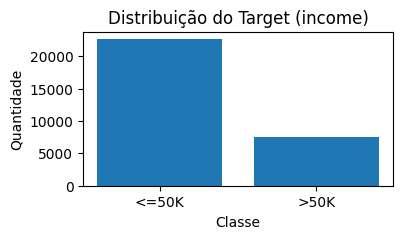

Há um claro desbalancemanto entre as classes do target 'income'
Porcentagem de dados '<=50K': 75.10%
Porcentagem de dados '>50K': 24.90%
O que significa que um modelo que sempre chuta '<=50K' acerta aproximadamente 76% das vezes


In [164]:
import matplotlib.pyplot as plt

target_count = df["income"].value_counts()

plt.figure(figsize=(4,2))
plt.bar(target_count.index, target_count.values)

plt.title("Distribuição do Target (income)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

print("Há um claro desbalancemanto entre as classes do target 'income'")
total = len(df)
target_percent = (target_count / total) * 100
print(f"Porcentagem de dados '<=50K': {target_percent["<=50K"]:.2f}%")
print(f"Porcentagem de dados '>50K': {target_percent[">50K"]:.2f}%")
print("O que significa que um modelo que sempre chuta '<=50K' acerta aproximadamente 76% das vezes")

### 2.2 Distribuição de features numéricas com o target

In [ ]:
df["income_num"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

corr_num = df[features_num + ["income_num"]].corr()

print(corr_num["income_num"].sort_values(ascending=False))
print("\n")

print(f"education-num: {corr_num['income_num']['education-num']:.2f} = Correlação moderada positiva, pois quanto maior a escolaridade maior chance de ganhar >50K \n")
print(f"age: {corr_num['income_num']['age']:.2f} = Correlação fraca a moderada, pois pessoas mais velhas tendem a ganhar mais (carreira) \n")
print(f"hours-per-week: {corr_num['income_num']['hours-per-week']:.2f} = Correlação fraca a moderada, pois quem trabalha mais tende a ganhar mais \n")
print(f"capital-gain: {corr_num['income_num']['capital-gain']:.2f} = Correlação fraca a moderada, posi quem tem ganhos de capital tende a ganhar mais \n")
print(f"capital-loss: {corr_num['income_num']['capital-loss']:.2f} = Correlação fraca (Ainda tem alguma relação, mas menor) \n")
print(f"fnlwgt: {corr_num['income_num']['fnlwgt']:.2f} = Irrelevante, praticamente zero, ou seja, não tem relação com o target e pode ser ignorada")


income_num        1.000000
education-num     0.335413
age               0.242017
hours-per-week    0.229435
capital-gain      0.221204
capital-loss      0.150026
fnlwgt           -0.008992
Name: income_num, dtype: float64


education-num: 0.34 = Correlação moderada positiva, pois quanto maior a escolaridade maior chance de ganhar >50K 

age: 0.24 = Correlação fraca a moderada, pois pessoas mais velhas tendem a ganhar mais (carreira) 

hours-per-week: 0.23 = Correlação fraca a moderada, pois quem trabalha mais tende a ganhar mais 

capital-gain: 0.22 = Correlação fraca a moderada, posi quem tem ganhos de capital tende a ganhar mais 

capital-loss: 0.15 = Correlação fraca (Ainda tem alguma relação, mas menor) 

fnlwgt: -0.01 = Irrelevante, praticamente zero, ou seja, não tem relação com o target e pode ser ignorada


Observa-se que as variáveis **education-num**, **age** e **hours-per-week** apresentam as maiores correlações positivas com o target, indicando que maior escolaridade, idade e carga horária estão associadas a maiores rendimentos. No entanto, as correlações são moderadas, sugerindo que o problema depende da combinação de múltiplas variáveis.

### 2.3 Distribuição de features categóricas com o target

In [201]:
features_cat_sem_target = [c for c in features_cat if c != "income"]

distrib_cat_target = []
for classe in features_cat_sem_target:
    proporcoes = df.groupby(classe)["income"].apply(
        lambda x: (x == ">50K").mean() * 100 # Porporção de 0's e 1's em cada classe de cada coluna categórica
    )
    diferenca = proporcoes.max() - proporcoes.min()
    distrib_cat_target.append({"feature": classe, "diferenca em pp": diferenca})

distrib_cat_target_df = pd.DataFrame(distrib_cat_target).sort_values("diferenca em pp", ascending=False)
print(distrib_cat_target_df.round(2))

          feature  diferenca em pp
1       education            74.91
0       workclass            55.87
4    relationship            47.93
3      occupation            47.82
7  native-country            45.24
2  marital-status            42.78
6             sex            20.02
5            race            18.65


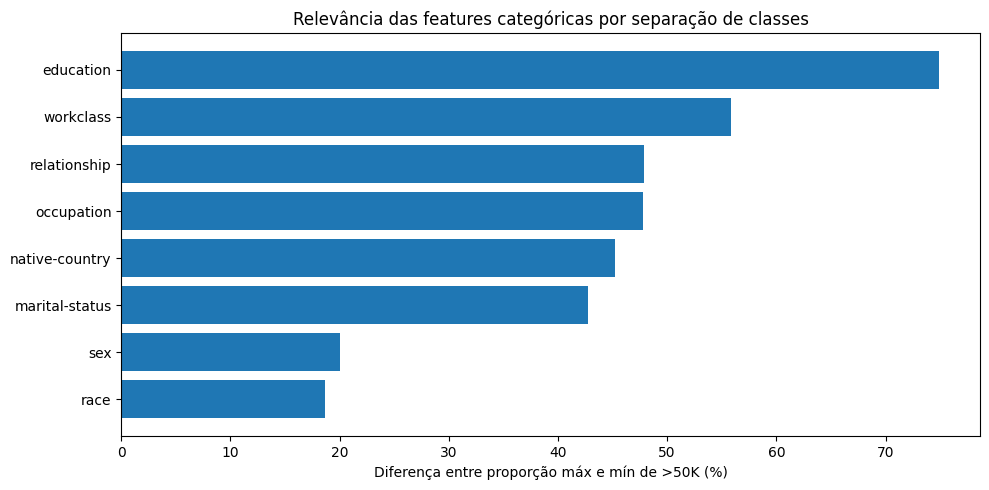

In [202]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(distrib_cat_target_df["feature"], distrib_cat_target_df["diferenca em pp"])
ax.set_xlabel("Diferença entre proporção máx e mín de >50K (%)")
ax.set_title("Relevância das features categóricas por separação de classes")
ax.invert_yaxis()
plt.tight_layout()
plt.show()